<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_0_Preliminaries/17_0_4_Residuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression Preliminaries: Residuals

---



## What This Notebook Is About

So far we have a nice story, but we still can't *predict* anything.

- Notebook 1 gave us a baseline model (just predict the mean) and a way to measure its typical error (the standard deviation).
- Notebook 2 taught us to always look at the data before modeling it.
- Notebook 3 gave us correlation, a single, unit-free number that says how strongly two variables move together.

But correlation doesn't make predictions. If a student studies for 3.5 hours, correlation can't tell us what score to expect. For that, we need to draw a line through the scatterplot and say *"for a student who studies for $x$ hours, we predict $\hat{y}$ on the exam."*

Before we learn how to pick the *best* line (that's the next notebook), we need to learn how to measure how wrong any given line is. The wrongness of a line at each point is called a **residual**, and residuals are the building block of nearly every regression concept that follows.

Two questions will drive this notebook:

1. What do we even mean by a "line's mistake" at a particular data point?
2. If we want to summarize a line's total wrongness in one number, why does it NOT work to just add up the residuals?

## Setup

For this notebook we're going to **step away from real datasets** and use a tiny synthetic one that has only 6 data points. Why? Because everything we do here you should be able to verify in your head. If the computer says a residual is $+10$, you should be able to glance at the table and confirm it.

The toy dataset: hours spent studying vs. exam score.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5.5)
plt.rcParams['axes.grid'] = True

df = pd.DataFrame({
    'Study_Hours': [1, 2, 3, 4, 5, 6],
    'Exam_Score':  [50, 55, 65, 70, 80, 85],
})
df

,Study_Hours,Exam_Score
0,1,50
1,2,55
2,3,65
3,4,70
4,5,80
5,6,85


---

## Section 1: Drawing an (Arbitrary) Line

Our goal is to build a rule that takes `Study_Hours` as an input and gives back a predicted `Exam_Score`. The simplest possible rule is a **straight line**, which you've known since algebra:

$$\hat{y} = m\,x + b$$

Where:

- $m$ is the **slope**, indicating how many points the predicted score goes up for each additional hour of studying.
- $b$ is the **intercept**, indicating the predicted score for a student who studies zero hours.

### Two symbols you must not confuse: $y$ vs. $\hat{y}$

Regression cares deeply about the difference between these two:

- $y_i$ (just "y") is the **actual** exam score student $i$ earned. It's a fact in our data.
- $\hat{y}_i$ ("y-hat") is the **predicted** score our line gives for student $i$. It's a guess.

Those are very different things. Read $\hat{y}$ as "model's best guess at y."

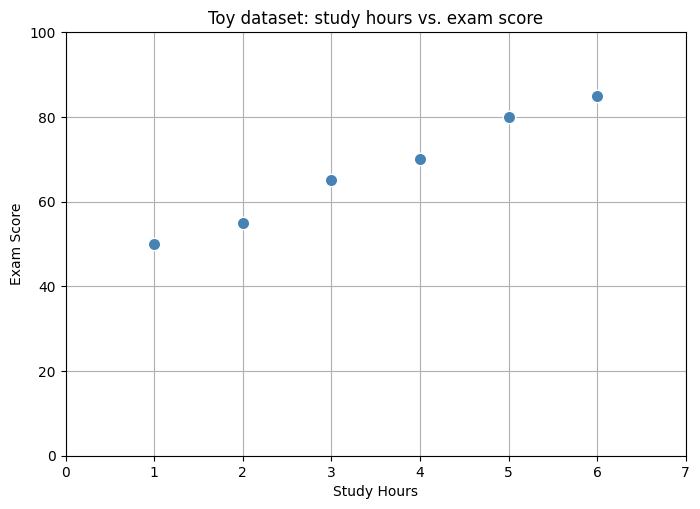

In [2]:
# First, just look at the data.
fig, ax = plt.subplots()
ax.scatter(df['Study_Hours'], df['Exam_Score'], s=80,
           color='steelblue', edgecolor='white', zorder=3)
ax.set_xlabel('Study Hours')
ax.set_ylabel('Exam Score')
ax.set_title('Toy dataset: study hours vs. exam score')
ax.set_ylim(0, 100)
ax.set_xlim(0, 7)
plt.show()

### The guessing game

Now we need a line. We're **not** going to use any fancy fitting procedure yet. We're just going to pick a slope and intercept, plug them in, and see what happens.

Let's guess: `m = 5` (each extra hour adds 5 points) and `b = 40` (a student who studies zero hours gets a 40).

Not a crazy guess. It should land somewhere in the right ballpark.

In [3]:
m = 5     # slope
b = 40    # intercept

# The predictions from our line: y_hat = m*x + b
df['Predicted_Score'] = m * df['Study_Hours'] + b
df

,Study_Hours,Exam_Score,Predicted_Score
0,1,50,45
1,2,55,50
2,3,65,55
3,4,70,60
4,5,80,65
5,6,85,70


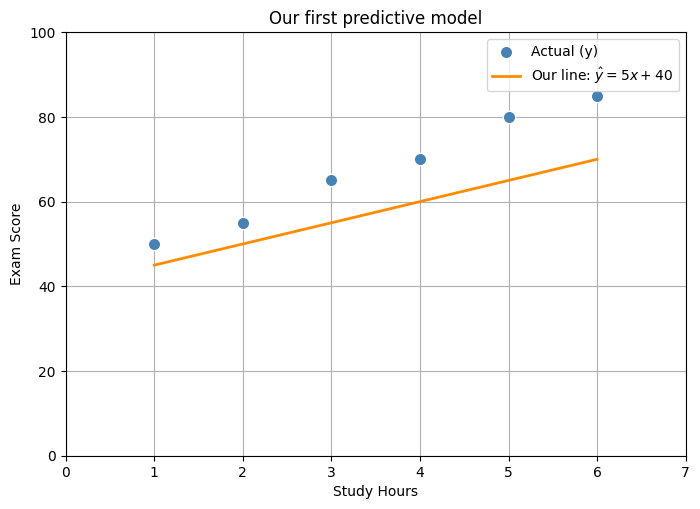

In [4]:
fig, ax = plt.subplots()
ax.scatter(df['Study_Hours'], df['Exam_Score'], s=80,
           color='steelblue', edgecolor='white', zorder=3,
           label='Actual (y)')
ax.plot(df['Study_Hours'], df['Predicted_Score'],
        color='darkorange', linewidth=2,
        label=fr'Our line: $\hat{{y}} = {m}x + {b}$')
ax.set_xlabel('Study Hours')
ax.set_ylabel('Exam Score')
ax.set_ylim(0, 100)
ax.set_xlim(0, 7)
ax.set_title('Our first predictive model')
ax.legend()
plt.show()

We have just built our first predictive machine-learning model.

It is almost certainly not a great model. But it is a model. Given a number of study hours, it commits to a predicted score. Now our job is to make the vague feeling of "this line is OK but a little low" into an actual number.

---

## Section 2: The Residual

### Definition

A model is only as good as its mistakes. So let's measure its mistakes.

For student $i$, the **residual** is the vertical distance from the actual point to our prediction line:

$$e_i = y_i - \hat{y}_i$$

("Actual minus predicted.") People also call this an "error" term. The sign matters:

- $e_i > 0$ → the actual score was *above* the line → we **under-predicted** this student.
- $e_i < 0$ → the actual score was *below* the line → we **over-predicted** this student.
- $e_i = 0$ → the dot is exactly on the line → perfect prediction for this student.

Let's compute them for all six students.

In [5]:
df['Residual'] = df['Exam_Score'] - df['Predicted_Score']
df

,Study_Hours,Exam_Score,Predicted_Score,Residual
0,1,50,45,5
1,2,55,50,5
2,3,65,55,10
3,4,70,60,10
4,5,80,65,15
5,6,85,70,15


**Pause and sanity-check the table yourself.** Pick any row: actual minus predicted. Does the residual match? For the student who studied 3 hours: actual was 65, predicted was 55, residual is $65 - 55 = +10$. The model under-predicted this student by 10 points. That's the whole idea.

Now let's *see* the residuals geometrically. We'll draw a vertical dashed line from each actual dot down (or up) to the prediction line. The *length* of each red dashed line is that row's residual.

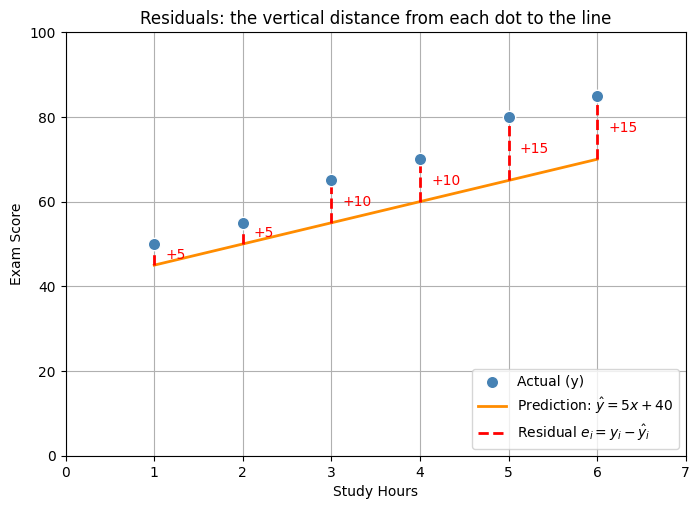

In [6]:
fig, ax = plt.subplots()

# The actual data
ax.scatter(df['Study_Hours'], df['Exam_Score'], s=80,
           color='steelblue', edgecolor='white', zorder=3,
           label='Actual (y)')

# Our prediction line
ax.plot(df['Study_Hours'], df['Predicted_Score'],
        color='darkorange', linewidth=2,
        label=fr'Prediction: $\hat{{y}} = {m}x + {b}$')

# The residuals: vertical lines from actual point to the prediction line
ax.vlines(df['Study_Hours'],
          ymin=df['Predicted_Score'],
          ymax=df['Exam_Score'],
          color='red', linestyle='--', linewidth=2,
          label='Residual $e_i = y_i - \\hat{y}_i$')

# Annotate each residual with its signed value for clarity
for _, row in df.iterrows():
    ax.annotate(f"{row['Residual']:+.0f}",
                xy=(row['Study_Hours'],
                    (row['Exam_Score'] + row['Predicted_Score']) / 2),
                xytext=(8, 0), textcoords='offset points',
                color='red', fontsize=10, va='center')

ax.set_xlabel('Study Hours')
ax.set_ylabel('Exam Score')
ax.set_ylim(0, 100)
ax.set_xlim(0, 7)
ax.set_title('Residuals: the vertical distance from each dot to the line')
ax.legend(loc='lower right')
plt.show()

Those red dashed segments are the residuals. They are the physical, geometric picture of what the model got wrong, student by student.

Notice the pattern here. Every residual is positive. All of the actual dots sit above our orange line. That's telling us our line is too low. It's systematically under-predicting. A better line would sit higher.

If we want to pick the best line out of all possible lines, we obviously need a way to summarize all six of these residuals into a single number that says "this line is X amount wrong, overall." That's our next step and it's where things get interesting.

---

## Section 3: The Trap of "Total Error"

### A tempting idea

To score our line, just add up the residuals. If the total is small, the line must be good. Let's try it.

In [7]:
print(f"Our line: y_hat = {m}x + {b}")
print(f"Sum of residuals: {df['Residual'].sum()}")

Our line: y_hat = 5x + 40
Sum of residuals: 60


For our line the residuals sum to 60. A number that seems to say "your line is about 60 points too low on average." Sounds roughly reasonable.

But now I'm going to draw a different line, and we'll compute the sum of residuals for it. I'll pick `m = -10` and `b = 102.5`.

Before we run the code: **take a moment to think about what this line says.** A slope of $-10$ means our model predicts that each additional hour of studying makes you lose 10 points on the exam. That is not just wrong. It's reality backwards. This is a terrible model.

In [8]:
m_bad = -10
b_bad = 102.5

df['Predicted_Score_bad'] = m_bad * df['Study_Hours'] + b_bad
df['Residual_bad']        = df['Exam_Score'] - df['Predicted_Score_bad']

print(df[['Study_Hours', 'Exam_Score', 'Predicted_Score_bad', 'Residual_bad']])
print()
print(f"Sum of residuals for the TERRIBLE line: {df['Residual_bad'].sum()}")

   Study_Hours  Exam_Score  Predicted_Score_bad  Residual_bad
0            1          50                 92.5         -42.5
1            2          55                 82.5         -27.5
2            3          65                 72.5          -7.5
3            4          70                 62.5           7.5
4            5          80                 52.5          27.5
5            6          85                 42.5          42.5

Sum of residuals for the TERRIBLE line: 0.0


**The sum of residuals is exactly zero.**

By our "total error" metric, this terrible line is *better* than our first line. It has zero total error. It is, according to this metric, a *perfect* model.

Let's look at it.

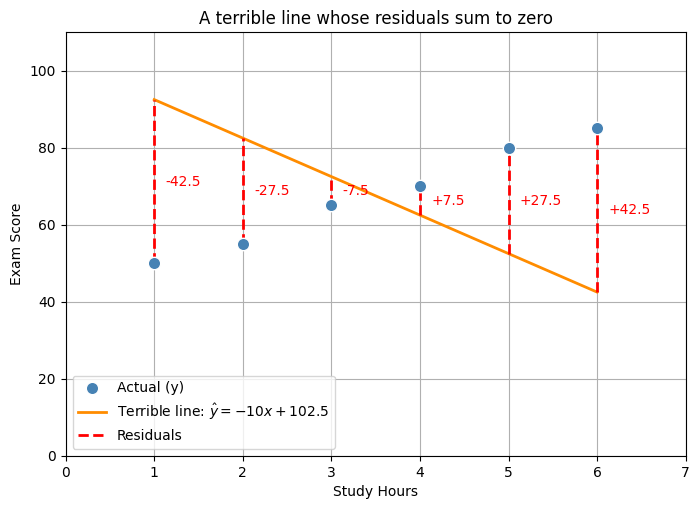

In [9]:
fig, ax = plt.subplots()
ax.scatter(df['Study_Hours'], df['Exam_Score'], s=80,
           color='steelblue', edgecolor='white', zorder=3,
           label='Actual (y)')
ax.plot(df['Study_Hours'], df['Predicted_Score_bad'],
        color='darkorange', linewidth=2,
        label=fr'Terrible line: $\hat{{y}} = {m_bad}x + {b_bad}$')
ax.vlines(df['Study_Hours'],
          ymin=df[['Predicted_Score_bad', 'Exam_Score']].min(axis=1),
          ymax=df[['Predicted_Score_bad', 'Exam_Score']].max(axis=1),
          color='red', linestyle='--', linewidth=2,
          label='Residuals')

for _, row in df.iterrows():
    ax.annotate(f"{row['Residual_bad']:+.1f}",
                xy=(row['Study_Hours'],
                    (row['Exam_Score'] + row['Predicted_Score_bad']) / 2),
                xytext=(8, 0), textcoords='offset points',
                color='red', fontsize=10, va='center')

ax.set_xlabel('Study Hours')
ax.set_ylabel('Exam Score')
ax.set_ylim(0, 110)
ax.set_xlim(0, 7)
ax.set_title('A terrible line whose residuals sum to zero')
ax.legend(loc='lower left')
plt.show()

Look at the residuals column in the table above. Half are large and positive ($+42.5, +27.5, +7.5$) and half are large and negative ($-7.5, -27.5, -42.5$). They are symmetric around zero, so when you add them they cancel out perfectly.

If this feels familiar, it should: **this is exactly the same trap we hit in Notebook 1**, when we tried to sum the deviations from the mean and got zero. There, the "zero-cancellation" problem was actually a definition of the mean. Deviations from the mean must sum to zero.

The same is going on here. Any line that passes through the point $(\bar{x}, \bar{y})$ will have residuals that sum to zero. Our terrible line happens to do exactly that: at $x = 3.5$ (the mean of study hours), it predicts $-10(3.5) + 102.5 = 67.5$. Which is exactly the mean of the exam scores. Zero-sum residuals are cheap. Lots of lines achieve them, including lines that are backwards.

> **Moral: "Sum of residuals" is a useless metric for quality of fit. Positive errors and negative errors cancel, so two completely different lines can both score zero.**

We already know the fix. We faced exactly this problem in Notebook 1 when we tried to sum the deviations from the mean, and we solved it by **squaring** them. That turned all the values positive, prevented cancellation, and gave us TSS, variance, and standard deviation.

We're about to apply the exact same trick to residuals in the next notebook. In doing so we'll land on two of the most important quantities in all of regression.

---

## Putting It All Together

Vocabulary of this notebook:

| Symbol | Name | Meaning |
|---|---|---|
| $y_i$ | actual value | The real outcome for observation $i$ (a fact). |
| $\hat{y}_i$ | predicted value / "y-hat" | What our line guesses for observation $i$. |
| $m,\ b$ | slope, intercept | The two parameters that define a line $\hat{y} = mx + b$. |
| $e_i = y_i - \hat{y}_i$ | residual | Vertical distance from actual dot to the line. |

And the story we built:

1. To make predictions we draw a line $\hat{y} = mx + b$ through the data.
2. For each observation the **residual** $y_i - \hat{y}_i$ measures how wrong the line is — with a sign that tells us under- vs. over-prediction.
3. To compare one line against another we need a *single* summary number for total wrongness.
4. Naïvely summing the residuals **does not work** — positive and negative errors cancel, and even dreadful lines can sum to zero.

### Where We're Going Next

The fix is the same as it was in notebook 1: **square the residuals before summing.** Doing so gives us:

- the **Residual Sum of Squares (RSS)**, a proper summary of a line's total wrongness.
- And once we have RSS, comparing it against TSS (from Notebook 1) gives us **$R^2$**, which tells us what fraction of the baseline's original error we've managed to explain away.

That's the [final preliminaries notebook---->](https://github.com/bsheese/cs377/blob/main/17_regression_crossval/17_0_Preliminaries/17_0_5_Rsquared.ipynb)